In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import re

explore our data set

In [3]:
### loading the data
df = pd.read_csv("aa_dataset-tickets-multi-lang-5-2-50-version.csv")
df.head(1)

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN


In [4]:
df.columns

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8'],
      dtype='object')

# predicting type using subject + body

In [5]:
### define a new df with subject and body and type
df_type = df[["subject", "body", "type"]]
df_type.head(1)

,subject,body,type
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Incident


In [6]:
### check how many rows we have
len(df_type)

28587

In [7]:
### check the unigue values in type
df_type["type"].unique()

array(['Incident', 'Request', 'Problem', 'Change'], dtype=object)

In [8]:
### check for missing values
df_type.isnull().sum()

subject    3838
body          0
type          0
dtype: int64

In [9]:
### fill the missing valuse in subject with UNKOWN
df_type["subject"] = df_type["subject"].fillna("UNKNOWN")

/tmp/ipykernel_11755/1878882424.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_type["subject"] = df_type["subject"].fillna("UNKNOWN")


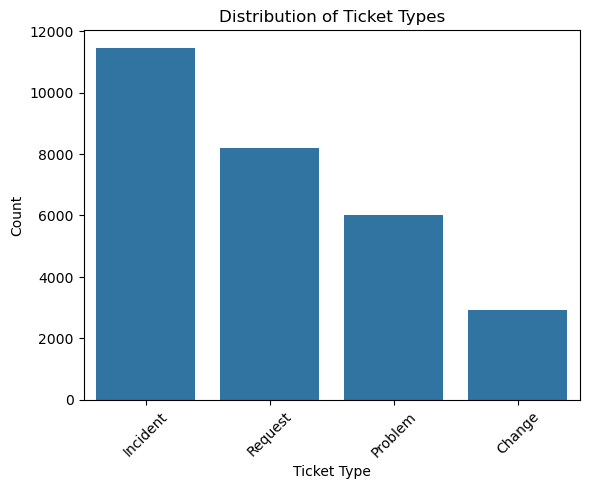

In [10]:
### Check class imbalanc
sns.countplot(x="type", data=df_type)
plt.title("Distribution of Ticket Types")
plt.xlabel("Ticket Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [11]:
### check the Duplicates
df_type.duplicated().sum()

np.int64(0)

/tmp/ipykernel_11755/2724251338.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_type["body_length"] = df_type["body"].apply(lambda x: len(str(x)))


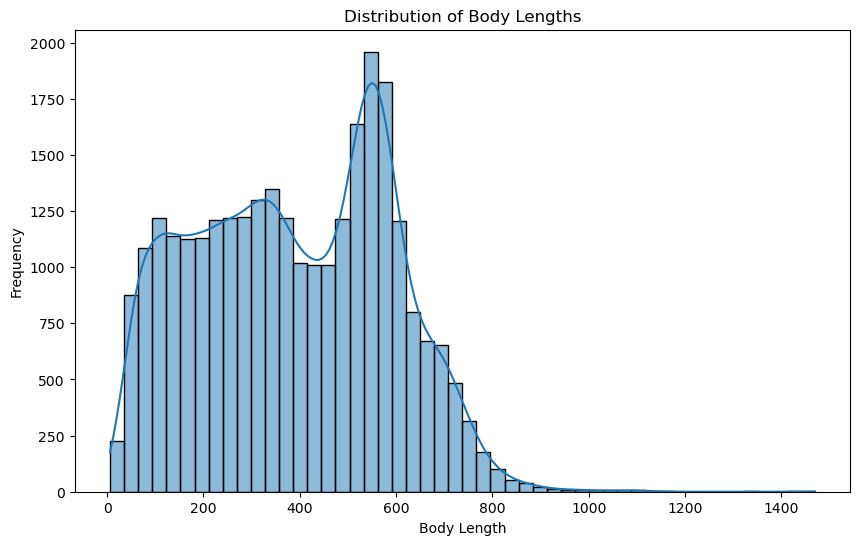

In [12]:
### Extremely long / short texts
df_type["body_length"] = df_type["body"].apply(lambda x: len(str(x)))
plt.figure(figsize=(10, 6))
sns.histplot(df_type["body_length"], bins=50, kde=True)
plt.title("Distribution of Body Lengths")
plt.xlabel("Body Length")
plt.ylabel("Frequency")
plt.show()

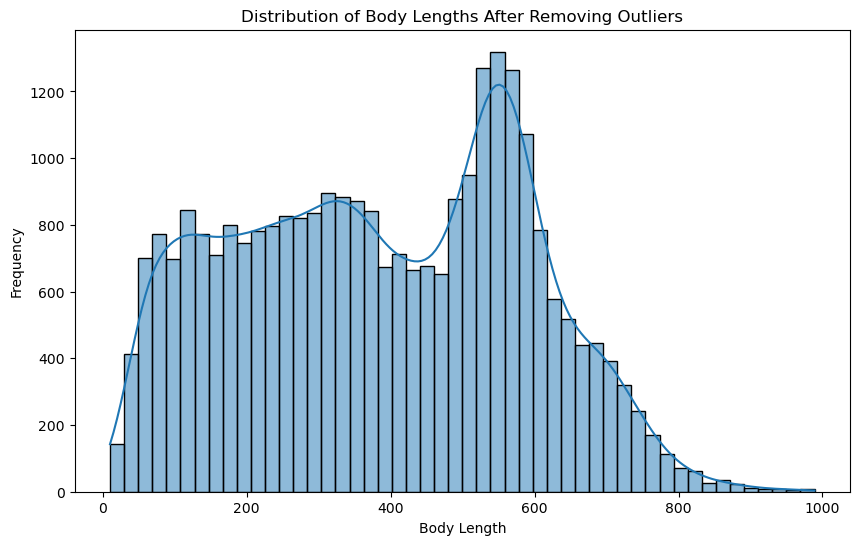

In [13]:
### remove the rows with body length less than 10
df_type = df_type[df_type["body_length"] >= 10]
### remove the rows with body length more than 1000
df_type = df_type[df_type["body_length"] <= 1000]
### check the distribution of body length after removing the outliers
plt.figure(figsize=(10, 6))
sns.histplot(df_type["body_length"], bins=50, kde=True)
plt.title("Distribution of Body Lengths After Removing Outliers")   
plt.xlabel("Body Length")
plt.ylabel("Frequency")
plt.show()

In [14]:
### print all charachters in body
all_characters = set("".join(df_type["body"].astype(str)))
print(all_characters)   

{'Z', ';', 'g', 'õ', '<', 'T', 's', 'è', 'Ö', ':', '%', 'F', '1', 'U', 'Ü', 'j', 'L', 'o', 'Q', '[', 'v', 'k', 'q', 'i', 'W', 'A', '7', 'X', 'E', 'H', '(', 'K', 'I', 'Y', '?', 'N', 'w', 'ã', 'r', 'Ä', 'h', 'C', 'l', 'p', ']', 'G', 'a', '3', '+', 'ç', 'e', '0', 'S', 'ö', '>', 'é', '4', 'z', 'x', '/', "'", '5', 'J', '2', '9', 'ä', '\\', 'O', 'D', 'm', 'b', 'à', 'n', '.', '"', 'á', 'V', '6', ' ', 'u', 't', 'y', 'R', 'f', 'B', 'P', '8', 'ú', 'ü', '#', ',', ')', '_', 'M', 'ó', 'í', 'd', '!', '-', 'ß', 'c', 'ê'}


In [16]:
df_type.columns

Index(['subject', 'body', 'type', 'body_length'], dtype='object')

In [17]:
### make a new column with subject and body combined as text
df_type["text"] = df_type["subject"] + " " + df_type["body"]
### lowercase the text
df_type["text"] = df_type["text"].str.lower()
df_type.head(1)

,subject,body,type,body_length,text
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Incident,751,wesentlicher sicherheitsvorfall sehr geehrtes ...


In [18]:
### drop all the columns except text and type
df_type = df_type[["text", "type"]]
df_type.head(1)

,text,type
0,wesentlicher sicherheitsvorfall sehr geehrtes ...,Incident


In [19]:
### normalize spaces in text
df_type["text"] = df_type["text"].apply(lambda x: re.sub(r"\s+", " ", x).strip())
df_type.head(1)

,text,type
0,wesentlicher sicherheitsvorfall sehr geehrtes ...,Incident


In [22]:
### split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    df_type["text"], df_type["type"], test_size=0.2, random_state=42
)  

In [23]:
### tf-idf vectorization
from sklearn.feature_extraction.text import TfidfVectorizer 
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [24]:
### train a logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
### model evaluation
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

      Change       0.98      0.93      0.95       589
    Incident       0.75      0.87      0.80      2305
     Problem       0.64      0.43      0.52      1194
     Request       0.98      1.00      0.99      1623

    accuracy                           0.82      5711
   macro avg       0.84      0.81      0.81      5711
weighted avg       0.81      0.82      0.81      5711



In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)  


[[ 546   10    4   29]
 [   6 2006  286    7]
 [   0  672  517    5]
 [   3    2    1 1617]]


In [31]:
### using tfidf bigrams
tfidf_bigram = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)
X_train_tfidf_bigram = tfidf_bigram.fit_transform(X_train)
X_test_tfidf_bigram = tfidf_bigram.transform(X_test)

model_bigram = LogisticRegression(max_iter=1000,class_weight="balanced",)
model_bigram.fit(X_train_tfidf_bigram, y_train)
y_pred_bigram = model_bigram.predict(X_test_tfidf_bigram)
print(classification_report(y_test, y_pred_bigram))

              precision    recall  f1-score   support

      Change       0.96      0.96      0.96       589
    Incident       0.84      0.77      0.81      2305
     Problem       0.63      0.72      0.67      1194
     Request       0.98      0.99      0.99      1623

    accuracy                           0.84      5711
   macro avg       0.85      0.86      0.86      5711
weighted avg       0.85      0.84      0.85      5711



In [34]:
from sklearn.svm import LinearSVC
model = LinearSVC(class_weight="balanced")
model.fit(X_train_tfidf_bigram, y_train)
y_pred_svm = model.predict(X_test_tfidf_bigram)
print("svm",classification_report(y_test, y_pred_svm))

svm               precision    recall  f1-score   support

      Change       0.99      0.96      0.98       589
    Incident       0.84      0.88      0.86      2305
     Problem       0.74      0.68      0.71      1194
     Request       0.99      1.00      0.99      1623

    accuracy                           0.88      5711
   macro avg       0.89      0.88      0.88      5711
weighted avg       0.88      0.88      0.88      5711



In [35]:
### encode the type column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)